In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

In [23]:
# Load clinical dataset
df = pd.read_csv(r"D:\DP\Table_clinical_data.csv", encoding="cp1252")
df.head()

,Patient ID,line of treatment,M-protein type,Light chain type,Serum M-protein quantity (g/l),Serum kappa FLC quantity (mg/l,Serum lambda FLC quantity (mg/l),IgG quantity (g/l),IgA quantity (g/l),IgM quantity (g/l),Plasmocyte count FC (%),Flow cytometry – circulating plasma cells (peripheral blood),Calcium total level (mmol/l),Creatinine level (µmol/l),Beta2 microglobulin (mg/l),ISS classification,Treatment regimen,Maximal response to treatment,MM associated amyloidosis,Follow - up
0,Myel_001,1st line,IgG,Kappa,21.4,143.00,9.25,32.87,1.59,0.82,0.86,NaN,2.37,81.0,2.02,Stage 1,bortezomib + lenalidomid + dexamethason,MR,no,NaN
1,Myel_002,1st line,IgA,Kappa,1.0,8870.00,2.10,1.90,0.73,0.05,12.00,NaN,2.44,51.0,4.71,Stage 2,bortezomib + cyklofosfamid + dexamethason,NaN,no,NaN
2,Myel_003,1st line,IgG,Kappa,1.1,287.00,7.46,6.66,0.87,0.28,6.50,yes,2.46,56.0,1.57,Stage 1,bortezomib + lenalidomid + dexamethason,VGPR,no,NaN
3,Myel_004,1st line,IgA,Kappa,0.0,1585.17,4.64,6.30,2.23,0.51,NaN,NaN,2.24,169.0,5.89,Stage 3,bortezomib + lenalidomid + dexamethason,VGPR,no,NaN
4,Myel_005,1st line,IgA,Lambda,14.8,23.40,1219.00,4.48,30.19,0.14,4.00,yes,2.22,189.0,15.75,Stage 3,bortezomib + lenalidomid + dexamethason,VGPR,no,NaN


In [24]:
nan_counts = df.isna().sum()
print(nan_counts)

Patient ID                                                       0
line of treatment                                                4
M-protein type                                                   0
Light chain type                                                 0
Serum M-protein quantity (g/l)                                  12
Serum kappa FLC quantity (mg/l                                  10
Serum lambda FLC quantity (mg/l)                                10
IgG quantity (g/l)                                               3
IgA quantity (g/l)                                               4
IgM quantity (g/l)                                               4
Plasmocyte count FC (%)                                         19
Flow cytometry – circulating plasma cells (peripheral blood)    19
Calcium total level (mmol/l)                                     2
Creatinine level (µmol/l)                                        2
Beta2 microglobulin (mg/l)                                    

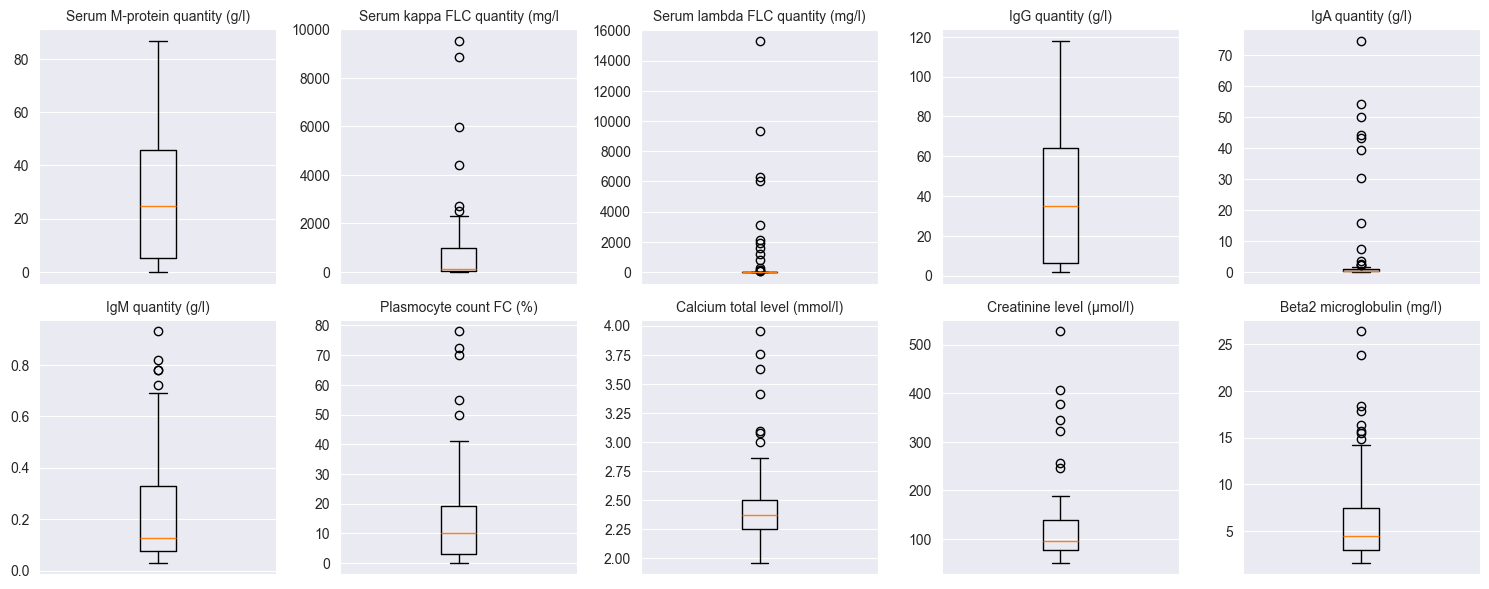

In [25]:
# BOXPLOT VISUALIZATION
numeric_cols = df.select_dtypes(include=['number']).columns

n_cols = len(numeric_cols)
cols_per_row = 5
rows = (n_cols + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(cols_per_row*3, rows*3))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols_per_row, i+1)
    plt.boxplot(df[col].dropna())
    plt.title(col, fontsize=10)
    plt.xticks([])
plt.tight_layout()
plt.show()

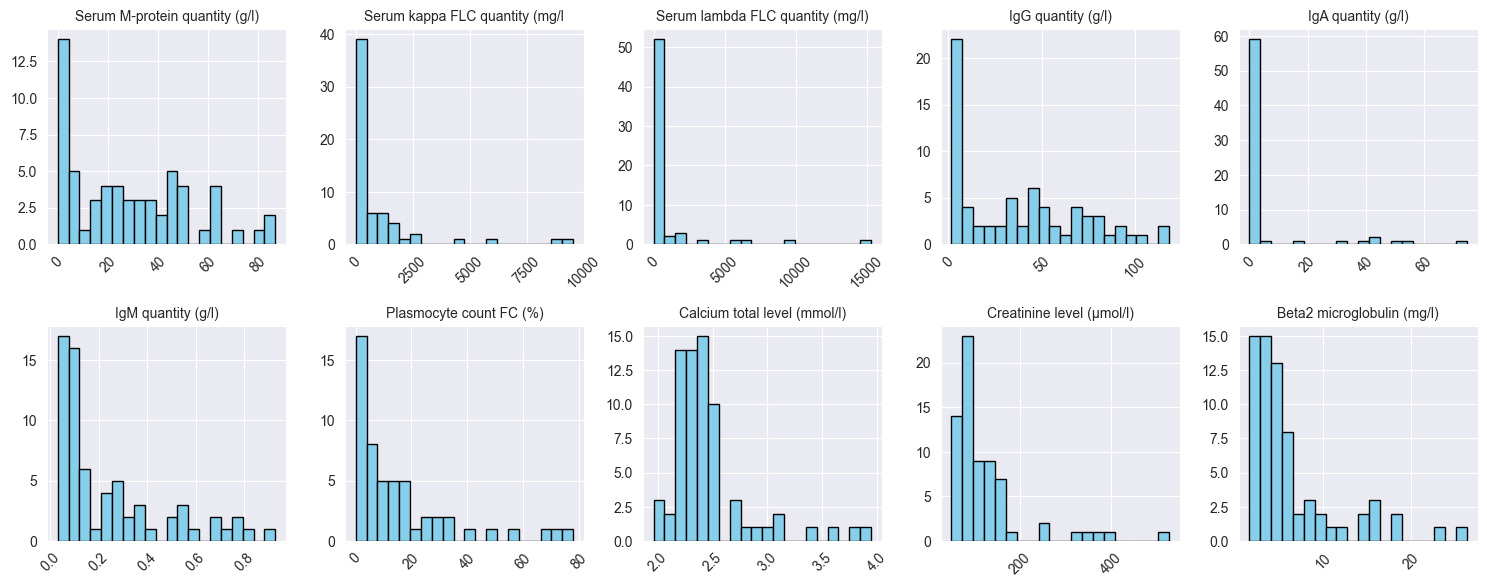

In [26]:
# HISTOGRAM VISUALIZATION
plt.figure(figsize=(cols_per_row*3, rows*3))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols_per_row, i+1)
    plt.hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(col, fontsize=10)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

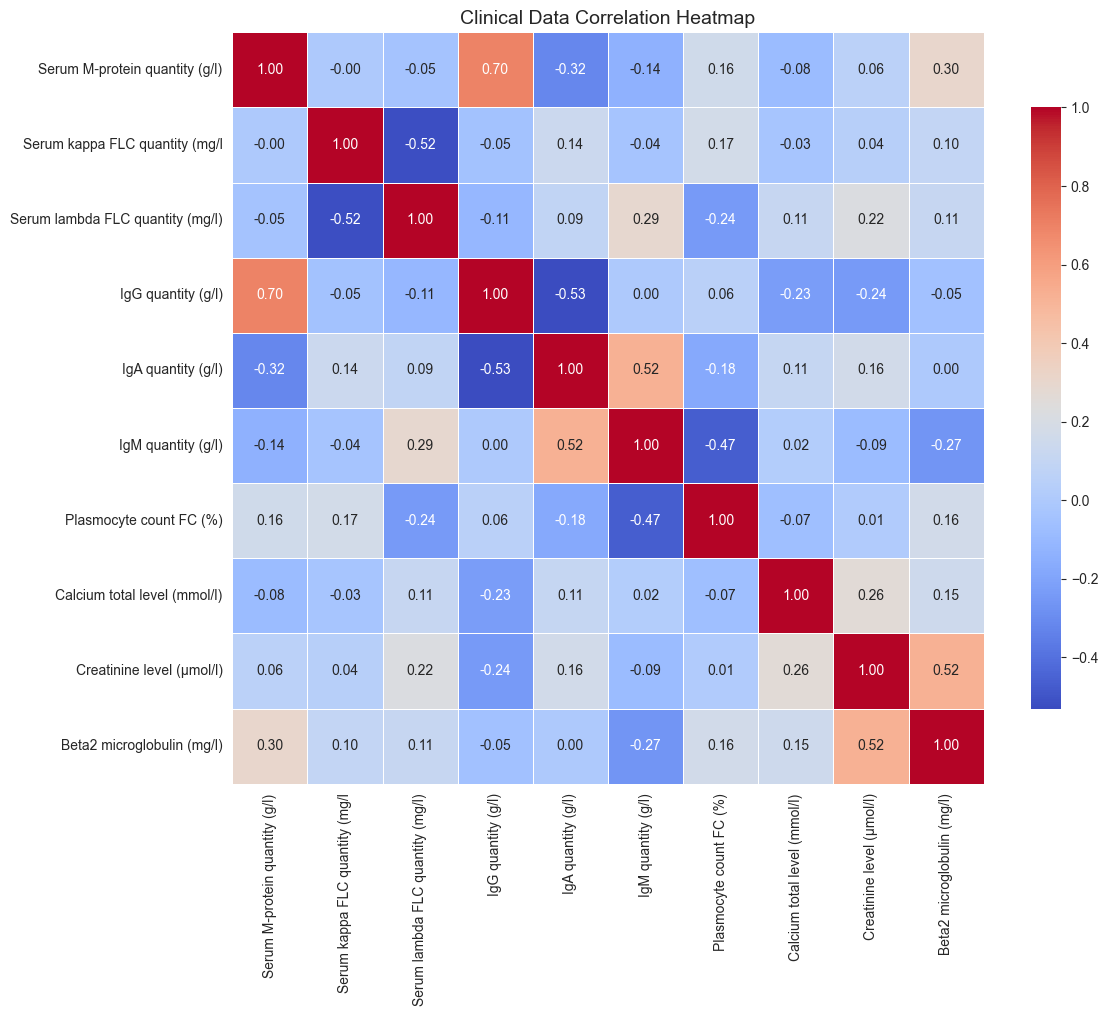

In [27]:
# HEATMAP
plt.figure(figsize=(12,10))
corr = df[numeric_cols].corr(method="spearman")  # pearson/spearman
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Clinical Data Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
# NORMALITY TEST
for column in numeric_cols:
    data = df[column].dropna()
    if len(data) < 3:
        continue
    _, p = shapiro(data)
    print(f"{column}: {p} -> Normality: {p > 0.05}")

Serum M-protein quantity (g/l): 0.00079869496824886 -> Normality: False
Serum kappa FLC quantity (mg/l: 8.797125616012289e-13 -> Normality: False
Serum lambda FLC quantity (mg/l): 5.578054498564823e-15 -> Normality: False
IgG quantity (g/l): 3.3747953240441965e-05 -> Normality: False
IgA quantity (g/l): 6.7925865431204356e-15 -> Normality: False
IgM quantity (g/l): 2.9993118404976564e-08 -> Normality: False
Plasmocyte count FC (%): 7.600677260764896e-08 -> Normality: False
Calcium total level (mmol/l): 1.5001521184219956e-09 -> Normality: False
Creatinine level (µmol/l): 5.765492227746324e-11 -> Normality: False
Beta2 microglobulin (mg/l): 1.4214849185837948e-09 -> Normality: False


In [29]:
# NORMALITY TEST WITH REPLACED NANs
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

for column in numeric_cols:
    data = df[column].dropna()
    if len(data) < 3:
        continue
    _, p = shapiro(data)
    print(f"{column}: {p} -> Normality: {p > 0.05}")

Serum M-protein quantity (g/l): 0.0006557869470312215 -> Normality: False
Serum kappa FLC quantity (mg/l: 9.629975200574519e-14 -> Normality: False
Serum lambda FLC quantity (mg/l): 6.205371210439718e-16 -> Normality: False
IgG quantity (g/l): 4.5557415316359284e-05 -> Normality: False
IgA quantity (g/l): 3.64947404668128e-15 -> Normality: False
IgM quantity (g/l): 2.752376442995839e-08 -> Normality: False
Plasmocyte count FC (%): 1.3485966971532727e-09 -> Normality: False
Calcium total level (mmol/l): 9.718085817473016e-10 -> Normality: False
Creatinine level (µmol/l): 3.947100124722411e-11 -> Normality: False
Beta2 microglobulin (mg/l): 9.89038043819278e-10 -> Normality: False
